In [5]:
import sys
import os

# Add the project root (where the nn/ folder lives) to the import path
sys.path.insert(0, os.path.abspath('../..'))

# Now you can import from nn
from nn import network
from nn import mnist_loader

In [17]:
import numpy as np

train_data, validation_data, test_data = mnist_loader.load_data_wrapper('../../nn/mnist.pkl.gz')
train_data = list(train_data)
validation_data = list(validation_data)
test_data = list(test_data)

network1_accurracies = []

net = network.Network([784, 15, 10])
for _ in range(30):
    net.SGD(train_data, 1, 10, 3.0, test_data=test_data)
    network1_accurracies.append(net.evaluate(test_data) / len(test_data))
    print(network1_accurracies)
    
network2_accurracies = []

net = network.Network([784, 16, 16, 10])
for _ in range(30):
    net.SGD(train_data, 1, 10, 3.0, test_data=test_data)
    network2_accurracies.append(net.evaluate(test_data) / len(test_data))
    print(network2_accurracies)



Epoch 0 : 8901 / 10000 [921/980 1099/1135]
[0.8901]
Epoch 0 : 9072 / 10000 [925/980 1106/1135]
[0.8901, 0.9072]
Epoch 0 : 9033 / 10000 [927/980 1112/1135]
[0.8901, 0.9072, 0.9033]
Epoch 0 : 9110 / 10000 [938/980 1117/1135]
[0.8901, 0.9072, 0.9033, 0.911]
Epoch 0 : 9161 / 10000 [930/980 1107/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161]
Epoch 0 : 9182 / 10000 [936/980 1108/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182]
Epoch 0 : 9159 / 10000 [942/980 1110/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182, 0.9159]
Epoch 0 : 9192 / 10000 [918/980 1108/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182, 0.9159, 0.9192]
Epoch 0 : 9114 / 10000 [928/980 1114/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182, 0.9159, 0.9192, 0.9114]
Epoch 0 : 9177 / 10000 [948/980 1111/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182, 0.9159, 0.9192, 0.9114, 0.9177]
Epoch 0 : 9128 / 10000 [948/980 1087/1135]
[0.8901, 0.9072, 0.9033, 0.911, 0.9161, 0.9182, 0.9159, 0.9192, 0.9114, 0.9177, 0.91

In [18]:
# now let's do the digit darkness alg

darknesses = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
darkcnts = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
for i in range(len(train_data)):
    x, y = train_data[i]
    digit = np.argmax(y)
    darknesses[digit] += np.sum(x)
    darkcnts[digit] += 1

print(darknesses)
print(darkcnts)

darkaverages = [darknesses[i] / darkcnts[i] for i in range(10)]
print(darkaverages)

correct = 0
# now let's determine the accuracies on the test set for each digit
for i in range(len(test_data)):
    x, y = test_data[i]
    darkx = np.sum(x)
    digit = np.argmax(y)
    diffs = [abs(darkx - darkaverages[i]) for i in range(10)]
    predicted_digit = np.argmin(diffs)
    if predicted_digit == digit:
        correct += 1

acc = correct / len(test_data)
print(acc)

[np.float32(670105.44), np.float32(338751.56), np.float32(577750.75), np.float32(565552.3), np.float32(462677.4), np.float32(452161.62), np.float32(531654.1), np.float32(465123.3), np.float32(570777.94), np.float32(479075.66)]
[4932, 5678, 4968, 5101, 4859, 4506, 4951, 5175, 4842, 4988]
[np.float32(135.86891), np.float32(59.660366), np.float32(116.29443), np.float32(110.87087), np.float32(95.2207), np.float32(100.346565), np.float32(107.38318), np.float32(89.8789), np.float32(117.880615), np.float32(96.04564)]
0.2322


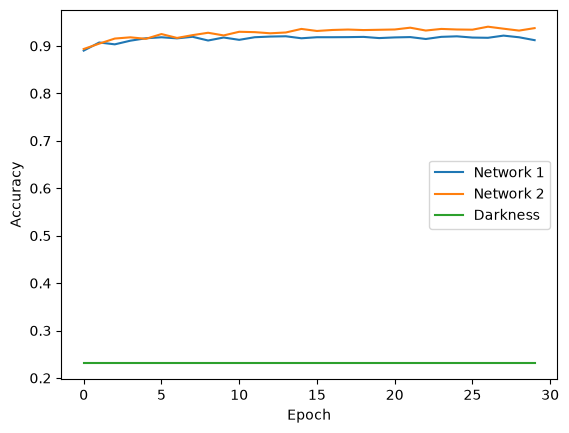

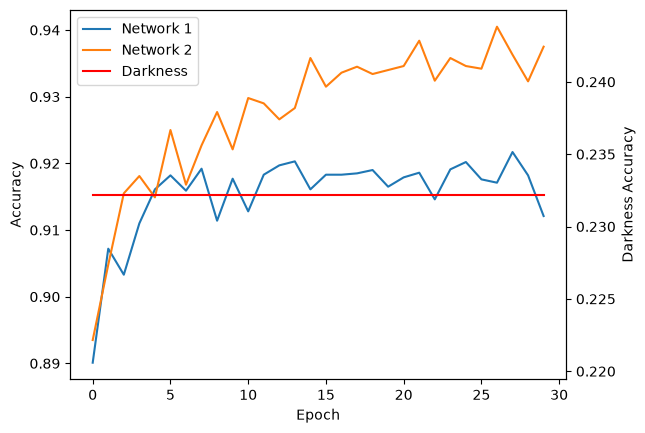

In [19]:
import matplotlib.pyplot as plt 

darkaccs = [acc for _ in range(30)]

plt.plot(range(30), network1_accurracies, label='Network 1')
plt.plot(range(30), network2_accurracies, label='Network 2')
plt.plot(range(30), darkaccs, label='Darkness')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

fig, ax1 = plt.subplots()
ax1.plot(range(30), network1_accurracies, label='Network 1')
ax1.plot(range(30), network2_accurracies, label='Network 2')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

ax2 = ax1.twinx()
ax2.plot(range(30), darkaccs, label='Darkness', color='red')
ax2.set_ylabel('Darkness Accuracy')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.show()